# Task 1.1 — Data Preparation and Validation Pipeline
**Unsupervised Learning Project 2025/2026 — Hotel Booking Demand**

## RQ1 — Segmentation Question

**Question:** Can we segment hotel guests into distinct travel-purpose profiles — particularly distinguishing business from leisure travellers — using only booking-time features such as lead time, length of stay, number of adults, and seasonality, in order to support hotel revenue management and tailored pricing strategies?

**Unit of analysis:** Each row represents one booking record (not a unique guest — the same guest may appear in multiple rows).

**Why clustering?** There are no predefined labels for guest travel purpose in the booking data. Clustering is appropriate because: (1) we operate in a fully unsupervised setting; (2) it discovers natural groupings empirically from booking patterns rather than forcing data into assumed business/leisure categories; and (3) it can reveal micro-segments with distinct behaviours that a simple binary classification would miss. To avoid leakage, only features known at or before booking time are used as clustering inputs.

## Data Documentation

- **Source:** Course release v1 — `hotel_bookings_course_release_v1.csv`
- **Original:** Kaggle — [jessemostipak/hotel-booking-demand](https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand/data)
- **Reference:** António, N., de Almeida, A., & Nunes, L. (2019). Hotel booking demand datasets. *Data in Brief*, 22, 41–49. https://doi.org/10.1016/j.dib.2018.11.126
- **License:** CC0 1.0 Public Domain (as stated in the course release)
- **What each row represents:** One hotel booking record (one stay or cancellation)
- **Time span:** Arrivals between July 2015 and August 2017, across two hotels (City Hotel and Resort Hotel)
- **Known data quality issues:**
  - `children`: 4 NaN values
  - `country`: ~0.4% missing values
  - `agent` / `company`: NULL encoded as the string `"NULL"` (not a proper NaN)
  - Some rows have 0 adults + 0 children + 0 babies (impossible — data entry error)
  - `adr` has at least one negative value (data entry error)

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import os
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

In [44]:
df_raw = pd.read_csv('hotel_bookings_course_release_v1.csv')
print('Shape:', df_raw.shape)
df_raw.head(3)

Shape: (119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02


## Leakage Control & Feature Exclusions

Clustering inputs must only use variables available **at booking time**. The following are excluded:

| Variable | Reason |
|---|---|
| `is_canceled` | Outcome variable — unknown at booking time |
| `reservation_status` | Post-event status — realised after the stay |
| `reservation_status_date` | Date of post-event status — post-arrival |
| `agent` | High-cardinality ID-like field (hundreds of numeric codes); no meaningful encoding |
| `company` | High-cardinality ID-like field; >90% NULL |
| `assigned_room_type` |  |
| `days_in_waiting_list` |  |

The outcome variables (`is_canceled`, `reservation_status`) are retained separately for **post-hoc profiling only**.

In [45]:
EXCLUDED = ['is_canceled', 'reservation_status', 'reservation_status_date', 'agent', 'company', 'assigned_room_type']

# Keep outcome vars for post-hoc profiling
df_labels = df_raw[['is_canceled', 'reservation_status']].copy()

df = df_raw.drop(columns=EXCLUDED).copy()
print('Shape after exclusions:', df.shape)

Shape after exclusions: (119390, 26)


## Data Quality Fixes

In [46]:
# Fix 1: children NaN -> 0 (no child is the correct interpretation for missing)
df['children'] = df['children'].fillna(0).astype(int)

# Fix 2: remove rows with 0 adults + 0 children + 0 babies (impossible)
zero_guests = (df['adults'] == 0) & (df['children'] == 0) & (df['babies'] == 0)
print(f'Zero-guest rows removed: {zero_guests.sum()}')
df = df[~zero_guests].copy()

# Fix 3: negative ADR -> NaN (will be median-imputed in pipeline)
neg_adr = df['adr'] < 0
print(f'Negative ADR values set to NaN: {neg_adr.sum()}')
df.loc[neg_adr, 'adr'] = np.nan

# Align profiling labels
df_labels = df_labels.loc[df.index]

print('Working dataset shape:', df.shape)

Zero-guest rows removed: 180
Negative ADR values set to NaN: 1
Working dataset shape: (119210, 26)


## Feature Set Definition

In [47]:
NUMERICAL = df.select_dtypes(include=[np.number]).columns.tolist()
CATEGORICAL = df.select_dtypes(exclude=[np.number]).columns.tolist()

print(f'Numerical features  ({len(NUMERICAL)}): {NUMERICAL}')
print(f'Categorical features ({len(CATEGORICAL)}): {CATEGORICAL}')

Numerical features  (17): ['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']
Categorical features (9): ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'deposit_type', 'customer_type']


## Missingness Report

In [48]:
df_features = df[NUMERICAL + CATEGORICAL].copy()

print('Missingness — Numerical features')
miss_num = df_features[NUMERICAL].isnull().sum()
miss_num_pct = (miss_num / len(df_features) * 100).round(3)
miss_num_df = pd.DataFrame({'n_missing': miss_num, 'pct_missing': miss_num_pct})
print(miss_num_df[miss_num_df['n_missing'] > 0].to_string())
print('(All others: 0 missing)' if (miss_num == 0).all() else '')

print()
print('Missingness — Categorical features')
miss_cat = df_features[CATEGORICAL].isnull().sum()
miss_cat_pct = (miss_cat / len(df_features) * 100).round(3)
miss_cat_df = pd.DataFrame({'n_missing': miss_cat, 'pct_missing': miss_cat_pct})
print(miss_cat_df[miss_cat_df['n_missing'] > 0].to_string())
if (miss_cat == 0).all():
    print('(All others: 0 missing)')

Missingness — Numerical features
     n_missing  pct_missing
adr          1        0.001


Missingness — Categorical features
         n_missing  pct_missing
country        478        0.401


## Outlier Report (Numerical — IQR method)

In [49]:
print('Outliers — Numerical features (IQR rule: outside Q1-1.5*IQR / Q3+1.5*IQR)')
rows = []
for col in NUMERICAL:
    s = df_features[col].dropna()
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out = ((s < lo) | (s > hi)).sum()
    rows.append({'feature': col, 'lower_fence': round(lo,2), 'upper_fence': round(hi,2),'n_outliers': n_out, 'pct': round(n_out/len(s)*100, 2)})

outlier_df = pd.DataFrame(rows).set_index('feature')
print(outlier_df.to_string())

print('Outliers — Categorical features')
print('Not applicable (no numerical range). Rare categories handled via frequency threshold in pipeline.')

Outliers — Numerical features (IQR rule: outside Q1-1.5*IQR / Q3+1.5*IQR)
                                lower_fence  upper_fence  n_outliers    pct
feature                                                                    
lead_time                           -196.50       375.50        2981   2.50
arrival_date_year                   2014.50      2018.50           0   0.00
arrival_date_week_number             -17.00        71.00           0   0.00
arrival_date_day_of_month            -14.50        45.50           0   0.00
stays_in_weekend_nights               -3.00         5.00         258   0.22
stays_in_week_nights                  -2.00         6.00        3330   2.79
adults                                 2.00         2.00       29530  24.77
children                               0.00         0.00        8590   7.21
babies                                 0.00         0.00         917   0.77
is_repeated_guest                      0.00         0.00        3755   3.15
previous_cance

## EDA — Univariate Distributions (Numerical)

Before clustering, we inspect the marginal distribution of each numerical feature. 

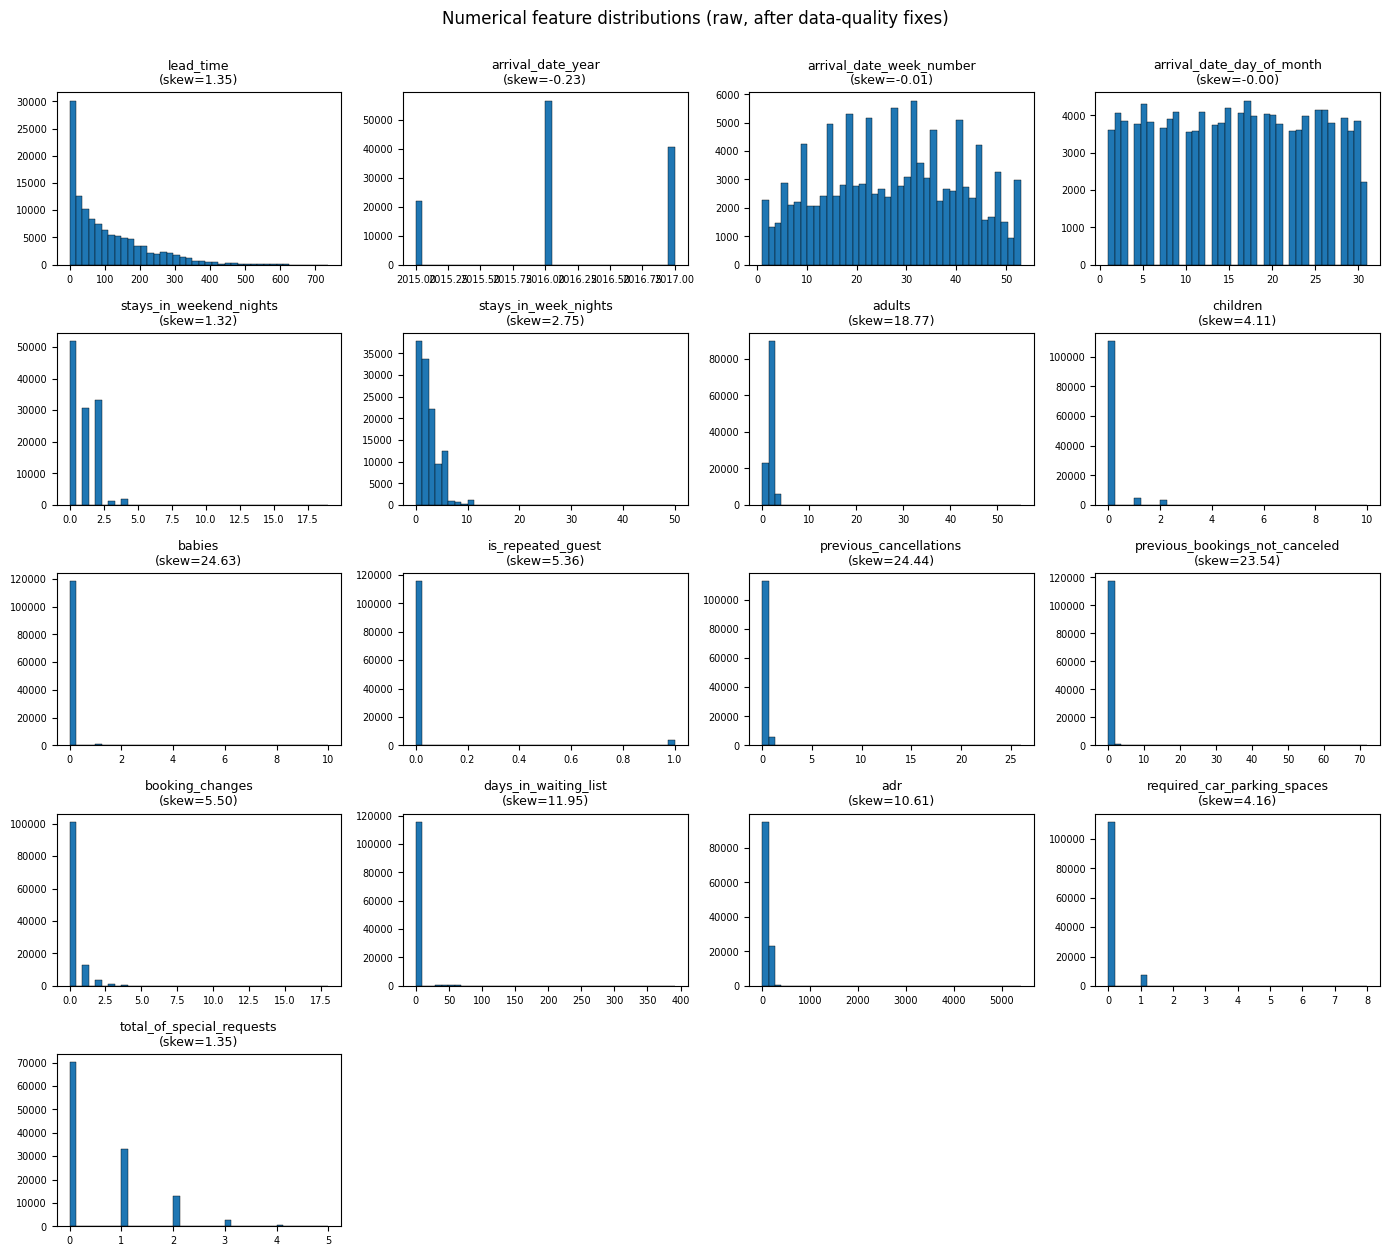


Features with |skew| > 2 (candidates for log-transform / robust scaling):
babies                            24.627962
previous_cancellations            24.443924
previous_bookings_not_canceled    23.539555
adults                            18.774333
days_in_waiting_list              11.948868
adr                               10.613328
booking_changes                    5.500058
is_repeated_guest                  5.364723
required_car_parking_spaces        4.162345
children                           4.109048
stays_in_week_nights               2.754863


In [50]:
import math

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
n = len(num_cols)
ncols = 4
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.5, nrows * 2.5))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    s = df[col].dropna()
    ax.hist(s, bins=40, edgecolor='black', linewidth=0.3)
    ax.set_title(f'{col}\n(skew={s.skew():.2f})', fontsize=9)
    ax.tick_params(labelsize=7)

for ax in axes[n:]:
    ax.set_visible(False)

plt.suptitle('Numerical feature distributions (raw, after data-quality fixes)', y=1.001)
plt.tight_layout()
plt.show()

# Highlight problematic features
print('\nFeatures with |skew| > 2 (candidates for log-transform / robust scaling):')
skews = df[num_cols].skew().abs().sort_values(ascending=False)
print(skews[skews > 2].to_string())

## EDA — Univariate Distributions (Categorical)

For each categorical feature we inspect its frequency distribution and cardinality. High-cardinality features (e.g. `country`) inflate the OHE space; the rare-category rollup (< 1% → "Other") is justified by the long tail visible here.

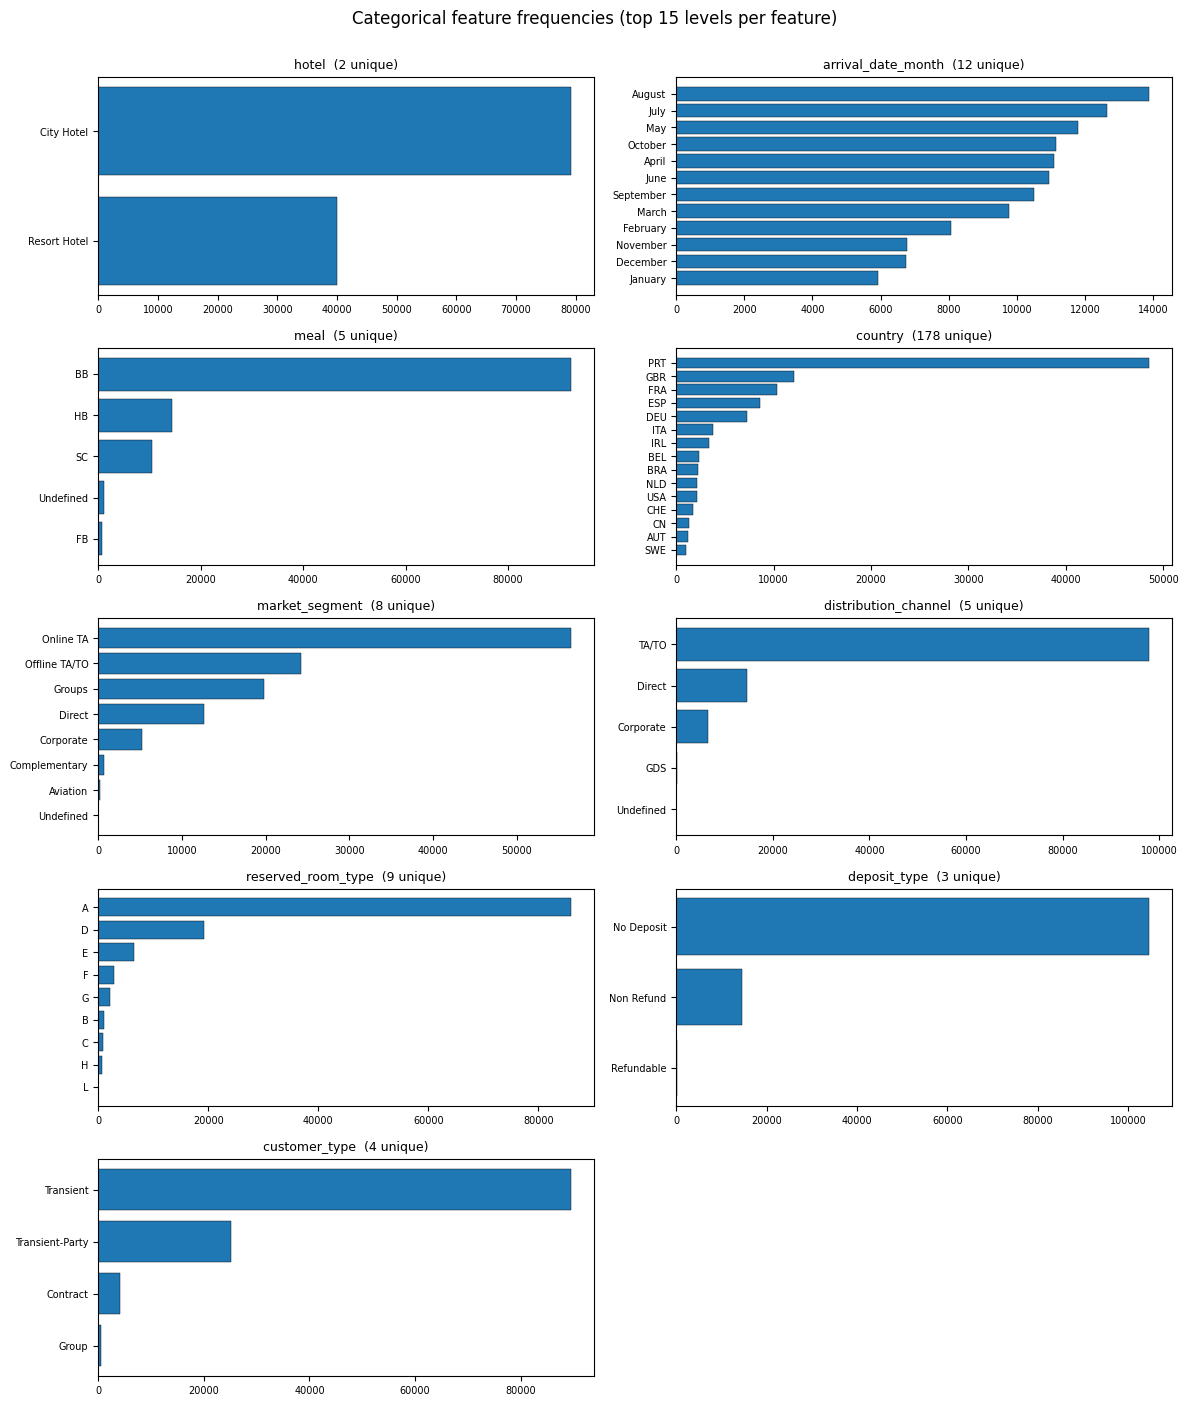


Cardinality summary:
             feature  n_unique        top  top_pct
               hotel         2 City Hotel     66.4
  arrival_date_month        12     August     11.6
                meal         5         BB     77.4
             country       178        PRT     40.7
      market_segment         8  Online TA     47.3
distribution_channel         5      TA/TO     82.0
  reserved_room_type         9          A     72.0
        deposit_type         3 No Deposit     87.6
       customer_type         4  Transient     75.1

Rare-category rollup preview (threshold = 1%):
  hotel                             0 rare levels  (0.0% of rows)
  arrival_date_month                0 rare levels  (0.0% of rows)
  meal                              2 rare levels  (1.7% of rows)
  country                         163 rare levels  (9.9% of rows)
  market_segment                    3 rare levels  (0.8% of rows)
  distribution_channel              2 rare levels  (0.2% of rows)
  reserved_room_type    

In [51]:
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
n = len(cat_cols)
ncols = 2
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 6, nrows * 2.8))
axes = axes.flatten() if n > 1 else [axes]

cardinality_report = []
for ax, col in zip(axes, cat_cols):
    vc = df[col].value_counts(dropna=False)
    n_unique = df[col].nunique(dropna=False)
    cardinality_report.append({'feature': col, 'n_unique': n_unique, 'top': vc.index[0], 'top_pct': round(vc.iloc[0] / len(df) * 100, 1)})

    top = vc.head(15)
    ax.barh(range(len(top)), top.values, edgecolor='black', linewidth=0.3)
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels(top.index, fontsize=7)
    ax.invert_yaxis()
    ax.set_title(f'{col}  ({n_unique} unique)', fontsize=9)
    ax.tick_params(axis='x', labelsize=7)

for ax in axes[n:]:
    ax.set_visible(False)

plt.suptitle('Categorical feature frequencies (top 15 levels per feature)', y=1.001)
plt.tight_layout()
plt.show()

print('\nCardinality summary:')
print(pd.DataFrame(cardinality_report).to_string(index=False))

# Rare-category preview: how many levels would be rolled up at the 1% threshold?
print('\nRare-category rollup preview (threshold = 1%):')
for col in cat_cols:
    freq = df[col].value_counts(normalize=True)
    n_rare = (freq < 0.01).sum()
    pct_rare_mass = freq[freq < 0.01].sum() * 100
    print(f'  {col:<30s}  {n_rare:3d} rare levels  ({pct_rare_mass:.1f}% of rows)')

## EDA — Pairwise Associations

We examine redundancy in the feature set: Pearson correlation between numerical features and Cramér's V between categorical features. Strongly associated pairs (e.g. `market_segment` vs `distribution_channel`) inflate the post-OHE space with redundant signal and motivate the dimensionality-reduction preprocessing variant.

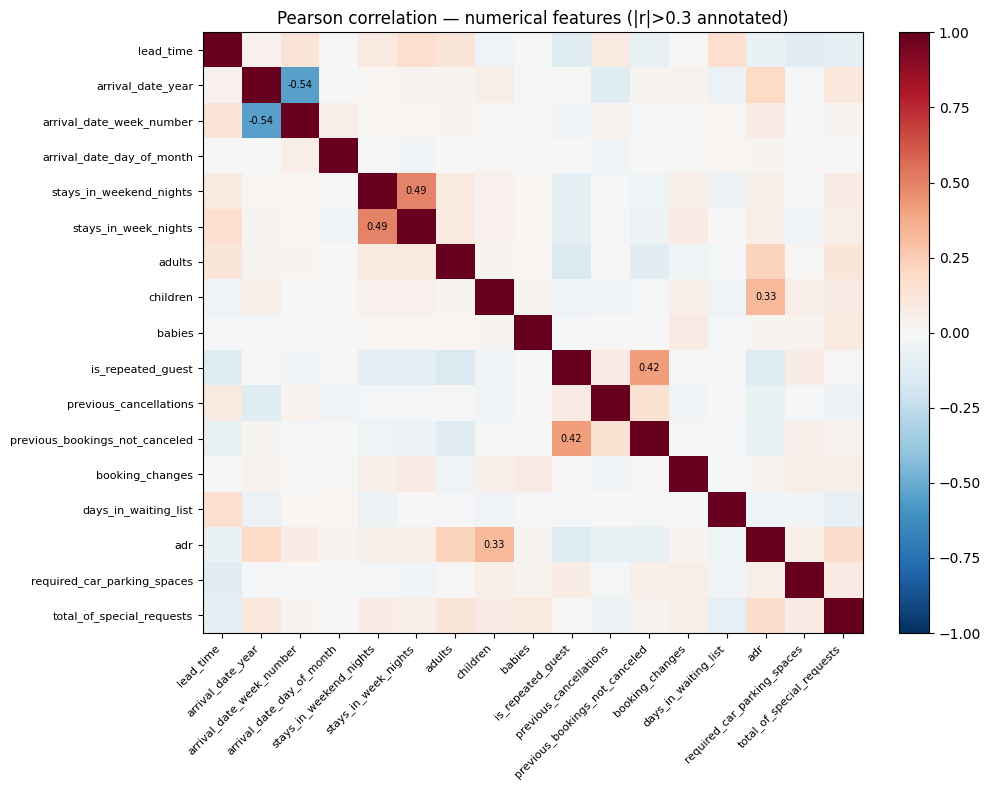


Top numerical correlations (|r| > 0.3):
                 feat_a                         feat_b  pearson_r
      arrival_date_year       arrival_date_week_number  -0.540373
stays_in_weekend_nights           stays_in_week_nights   0.494175
      is_repeated_guest previous_bookings_not_canceled   0.420642
               children                            adr   0.325059


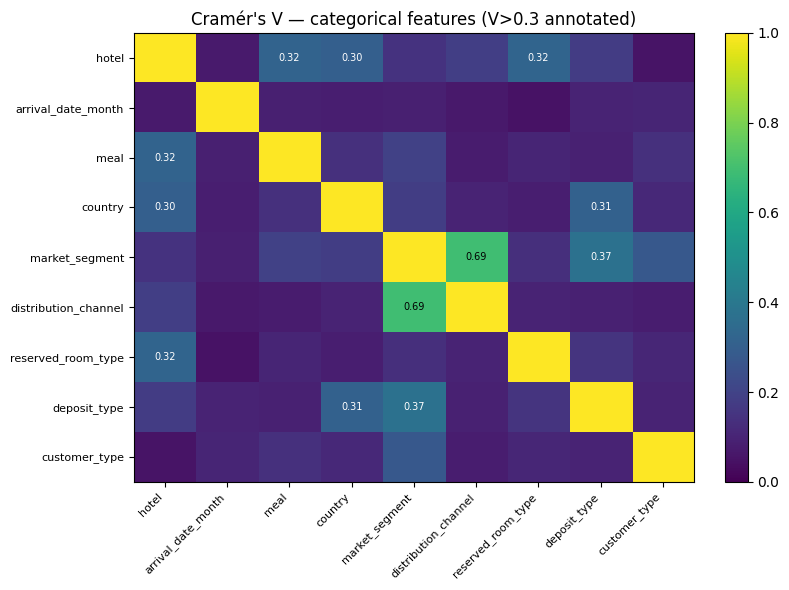


Top categorical associations (Cramér's V > 0.3):
        feat_a               feat_b  cramers_v
market_segment distribution_channel   0.692129
market_segment         deposit_type   0.374127
         hotel   reserved_room_type   0.323125
         hotel                 meal   0.316564
       country         deposit_type   0.312249
         hotel              country   0.301370


In [52]:
from scipy.stats import contingency

# numerical: pearson correlation
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(num_cols)))
ax.set_yticks(range(len(num_cols)))
ax.set_xticklabels(num_cols, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(num_cols, fontsize=8)
# Annotate cells with |r| > 0.3
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        r = corr.iloc[i, j]
        if abs(r) > 0.3 and i != j:
            ax.text(j, i, f'{r:.2f}', ha='center', va='center',
                    fontsize=7, color='white' if abs(r) > 0.6 else 'black')
plt.colorbar(im, ax=ax, fraction=0.046)
ax.set_title('Pearson correlation — numerical features (|r|>0.3 annotated)')
plt.tight_layout()
plt.show()

# top correlated pairs (excluding diagonal)
corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        .stack()
        .reset_index()
)
corr_pairs.columns = ['feat_a', 'feat_b', 'pearson_r']
corr_pairs['abs_r'] = corr_pairs['pearson_r'].abs()
print('\nTop numerical correlations (|r| > 0.3):')
print(corr_pairs[corr_pairs['abs_r'] > 0.3]
      .sort_values('abs_r', ascending=False)
      .drop(columns='abs_r')
      .to_string(index=False))


# categorical: cramér's V
def cramers_v(x, y):
    # bias-corrected Cramér's V (Bergsma 2013). Range [0, 1].
    cm = pd.crosstab(x, y).values
    chi2 = contingency.chi2_contingency(cm, correction=False)[0]
    n = cm.sum()
    r, k = cm.shape
    phi2 = chi2 / n
    phi2_corr = max(0, phi2 - (r - 1) * (k - 1) / (n - 1))
    r_corr = r - (r - 1) ** 2 / (n - 1)
    k_corr = k - (k - 1) ** 2 / (n - 1)
    denom = min(r_corr - 1, k_corr - 1)
    return np.sqrt(phi2_corr / denom) if denom > 0 else 0.0

cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
v_matrix = pd.DataFrame(np.zeros((len(cat_cols), len(cat_cols))),
                        index=cat_cols, columns=cat_cols)
for a in cat_cols:
    for b in cat_cols:
        v_matrix.loc[a, b] = cramers_v(df[a], df[b]) if a != b else 1.0

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(v_matrix, cmap='viridis', vmin=0, vmax=1, aspect='auto')
ax.set_xticks(range(len(cat_cols)))
ax.set_yticks(range(len(cat_cols)))
ax.set_xticklabels(cat_cols, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(cat_cols, fontsize=8)
for i in range(len(cat_cols)):
    for j in range(len(cat_cols)):
        v = v_matrix.iloc[i, j]
        if i != j and v > 0.3:
            ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                    fontsize=7, color='white' if v < 0.5 else 'black')
plt.colorbar(im, ax=ax, fraction=0.046)
ax.set_title("Cramér's V — categorical features (V>0.3 annotated)")
plt.tight_layout()
plt.show()

# top categorical associations
v_pairs = (
    v_matrix.where(np.triu(np.ones(v_matrix.shape), k=1).astype(bool))
            .stack()
            .reset_index()
)
v_pairs.columns = ['feat_a', 'feat_b', 'cramers_v']
print("\nTop categorical associations (Cramér's V > 0.3):")
print(v_pairs[v_pairs['cramers_v'] > 0.3]
      .sort_values('cramers_v', ascending=False)
      .to_string(index=False))

## EDA — Hotel Split (City vs Resort)

The dataset contains two distinct hotels (City Hotel and Resort Hotel) with very different operating profiles. Joint clustering risks rediscovering the hotel split as the dominant partition, which would be uninformative for RQ1 (travel-purpose segmentation). This panel quantifies the gap so we can defend the modelling choice in the report, understanding if we should cluster jointly with `hotel` as a feature, cluster jointly without it, or cluster per-hotel.

###  --- Interno ---
### Nota comparação de Cohen's *d*

Mede a diferença entre as médias de dois grupos em unidades de desvio-padrão combinado, ou seja, quão afastadas estão as duas distribuições, controlando o spread.

$$d = \frac{\bar{x}_1 - \bar{x}_2}{s_{\text{pooled}}}, \qquad s_{\text{pooled}} = \sqrt{\frac{s_1^2 + s_2^2}{2}}$$

**Porque é que faz sentido aqui:** diferenças de médias dependem das unidades (dizer que o `lead_time` do City Hotel é 30 dias superior ao do Resort não diz nada sem saber a variabilidade). Ao normalizar pelo spread, *d* fica comparável entre features com escalas diferentes (`adr` em €, `stays_in_week_nights` em contagem, `lead_time` em dias).

**Interpretação:**

| \|*d*\| | Magnitude |
|---|---|
| < 0.2 | negligível |
| 0.2 – 0.5 | pequena |
| 0.5 – 0.8 | média |
| > 0.8 | grande |
| > 1.2 | muito grande |

**Porque é o diagnóstico certo para clustering:** o k-means minimiza distância euclidiana ao quadrado no espaço standardizado. *d* é exactamente o rácio sinal-ruído por feature nesse mesmo espaço — uma feature com \|*d*\| > 0.8 entre City e Resort tem sinal suficiente, por si só, para o k-means redescobrir a separação por hotel como partição dominante. Isto antecipa quais as features que vão dominar a atribuição de clusters antes de treinarmos qualquer modelo, e ajuda a justificar se fazemos clustering conjunto, por hotel, ou excluindo a variável `hotel`.

**Caveats:** *d* assume distribuições aproximadamente normais e variâncias comparáveis. Várias features aqui (`lead_time`, `adr`) são right-skewed, portanto tratamos o *d* como estimativa de effect size e não como valor exacto. O teste não-paramétrico Mann–Whitney *U* (na variante report-ready da célula) é o complemento sem assunções sobre a distribuição.


Hotel breakdown:
hotel
City Hotel      79163
Resort Hotel    40047
Name: count, dtype: int64

Proportion: {'City Hotel': 66.4, 'Resort Hotel': 33.6}



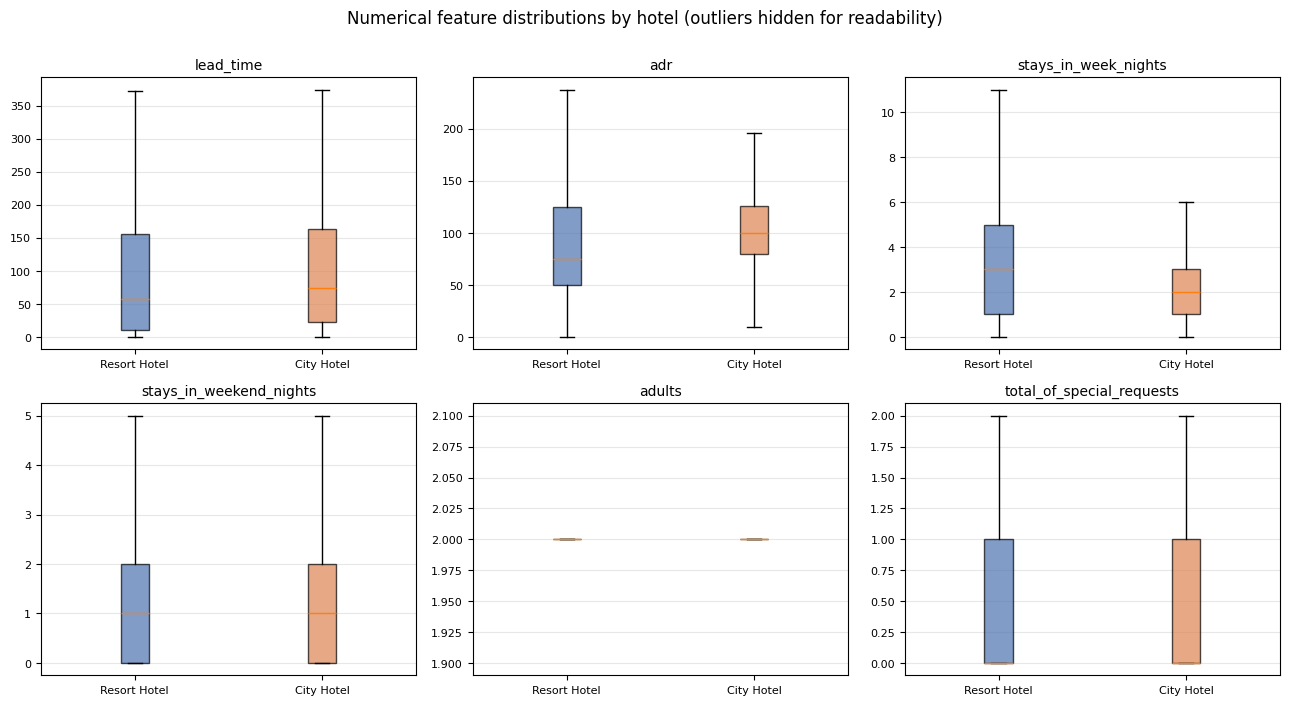

Median values by hotel + standardised mean difference (Cohen's d):
                  feature  median_City  median_Resort  cohens_d
                lead_time        74.00           57.0      0.16
                      adr        99.96           75.0      0.20
     stays_in_week_nights         2.00            3.0     -0.47
  stays_in_weekend_nights         1.00            1.0     -0.39
                   adults         2.00            2.0     -0.02
total_of_special_requests         0.00            0.0     -0.09

(|d| > 0.5 = medium effect, |d| > 0.8 = large — hotel split likely dominates clustering on those features)

Market segment share (%) by hotel:
hotel           City Hotel  Resort Hotel
market_segment                          
Aviation               0.3           0.0
Complementary          0.7           0.5
Corporate              3.8           5.8
Direct                 7.7          16.3
Groups                17.6          14.6
Offline TA/TO         21.1          18.7
Online TA    

In [53]:
hotel_col = 'hotel'

# sanity check
assert hotel_col in df.columns, f'Column "{hotel_col}" not found. Available: {df.columns.tolist()}'
print(f'Hotel breakdown:\n{df[hotel_col].value_counts()}\n')
print(f'Proportion: {(df[hotel_col].value_counts(normalize=True) * 100).round(1).to_dict()}\n')

# features to compare across hotels (RQ1-relevant)
compare_features = ['lead_time', 'adr', 'stays_in_week_nights',
                    'stays_in_weekend_nights', 'adults', 'total_of_special_requests']
compare_features = [c for c in compare_features if c in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
axes = axes.flatten()

for ax, col in zip(axes, compare_features):
    data_by_hotel = [df.loc[df[hotel_col] == h, col].dropna() for h in df[hotel_col].unique()]
    bp = ax.boxplot(data_by_hotel, labels=df[hotel_col].unique(), showfliers=False, patch_artist=True)
    for patch, color in zip(bp['boxes'], ['#4C72B0', '#DD8452']):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(col, fontsize=10)
    ax.tick_params(labelsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Numerical feature distributions by hotel (outliers hidden for readability)', y=1.001)
plt.tight_layout()
plt.show()

# comparison: medians and effect size
print('Median values by hotel + standardised mean difference (Cohen\'s d):')
rows = []
for col in compare_features:
    g1 = df.loc[df[hotel_col] == 'City Hotel',   col].dropna()
    g2 = df.loc[df[hotel_col] == 'Resort Hotel', col].dropna()
    pooled_std = np.sqrt(((g1.std() ** 2) + (g2.std() ** 2)) / 2)
    cohens_d = (g1.mean() - g2.mean()) / pooled_std if pooled_std > 0 else 0.0
    rows.append({
        'feature': col,
        'median_City':   round(g1.median(), 2),
        'median_Resort': round(g2.median(), 2),
        "cohens_d": round(cohens_d, 2),
    })
print(pd.DataFrame(rows).to_string(index=False))
print('\n(|d| > 0.5 = medium effect, |d| > 0.8 = large — hotel split likely dominates clustering on those features)')

# categorical : market segment composition by hotel
print('\nMarket segment share (%) by hotel:')
ms_share = (pd.crosstab(df['market_segment'], df[hotel_col], normalize='columns') * 100).round(1)
print(ms_share.to_string())

## EDA — Seasonality and Temporal Patterns

The research question explicitly mentions seasonality. The dataset covers Jul 2015 to Aug 2017 and contains temporal features (`arrival_date_year`, `arrival_date_month`, `arrival_date_week_number`). This section checks whether monthly patterns differ by hotel and whether `lead_time` varies with the montg. A typical signal for distinguishing leisure (longer lead times for peak months) vs business (shorter, more stable lead times).

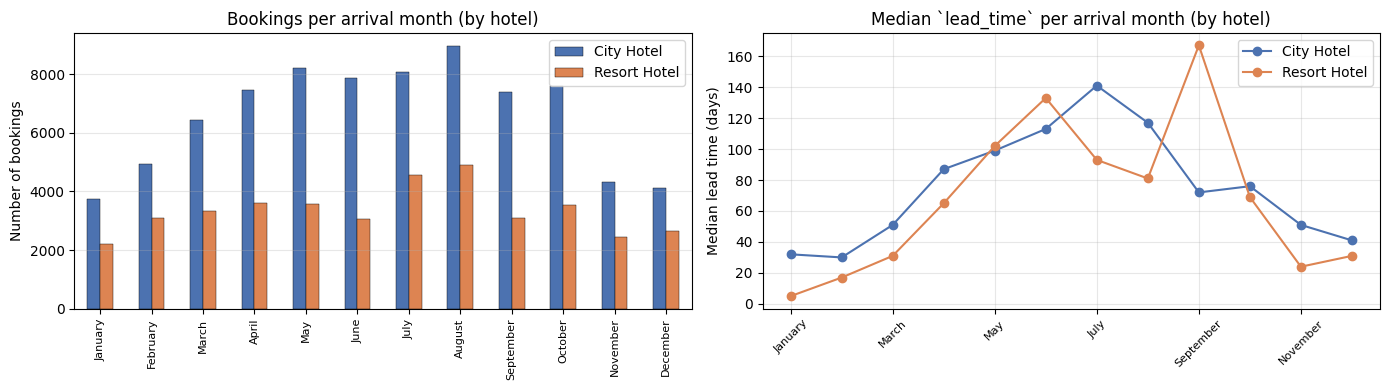

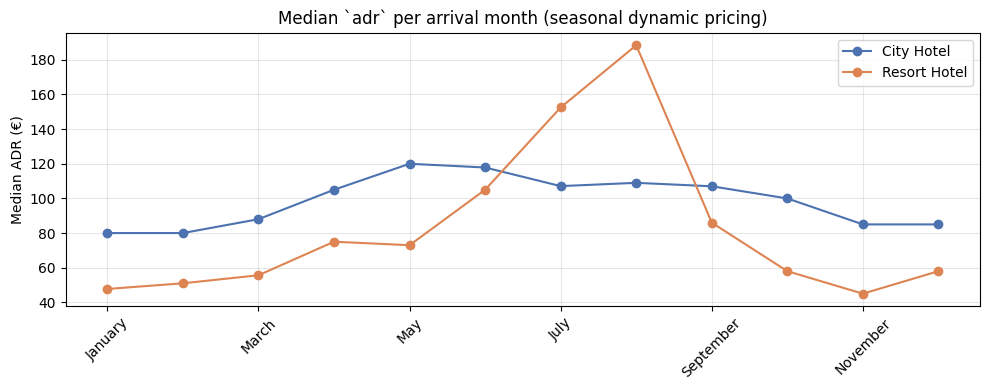

Seasonality summary — monthly coefficient of variation per hotel:
       hotel  cv_volume  cv_adr  cv_leadtime peak_month_volume peak_month_adr
Resort Hotel      0.238   0.543        0.730            August         August
  City Hotel      0.277   0.146        0.478            August            May

(Higher CV = stronger seasonality. Resort typically shows CV of volume and ADR 2-3x higher than City.)


In [54]:
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

# Ensure month is categorical with proper order for plotting
df_eda = df.copy()
df_eda['arrival_date_month'] = pd.Categorical(
    df_eda['arrival_date_month'], categories=month_order, ordered=True
)

# Panel 1: Bookings per month, split by hotel
month_by_hotel = pd.crosstab(df_eda['arrival_date_month'], df_eda['hotel'])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
month_by_hotel.plot(kind='bar', ax=axes[0], color=['#4C72B0', '#DD8452'], edgecolor='black', linewidth=0.3)
axes[0].set_title('Bookings per arrival month (by hotel)')
axes[0].set_ylabel('Number of bookings')
axes[0].set_xlabel('')
axes[0].legend(title='')
axes[0].tick_params(axis='x', labelsize=8)
axes[0].grid(axis='y', alpha=0.3)

# Panel 2: Median lead_time per month, split by hotel
lead_by_month = (df_eda.groupby(['arrival_date_month', 'hotel'], observed=False)['lead_time']
                       .median()
                       .unstack())
lead_by_month.plot(ax=axes[1], marker='o', color=['#4C72B0', '#DD8452'])
axes[1].set_title('Median `lead_time` per arrival month (by hotel)')
axes[1].set_ylabel('Median lead time (days)')
axes[1].set_xlabel('')
axes[1].legend(title='')
axes[1].tick_params(axis='x', rotation=45, labelsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Panel 3: ADR by month to capture peak-season pricing
fig, ax = plt.subplots(figsize=(10, 4))
adr_by_month = (df_eda.groupby(['arrival_date_month', 'hotel'], observed=False)['adr']
                      .median()
                      .unstack())
adr_by_month.plot(ax=ax, marker='o', color=['#4C72B0', '#DD8452'])
ax.set_title('Median `adr` per arrival month (seasonal dynamic pricing)')
ax.set_ylabel('Median ADR (€)')
ax.set_xlabel('')
ax.legend(title='')
ax.tick_params(axis='x', rotation=45)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Summary
print('Seasonality summary — monthly coefficient of variation per hotel:')
rows = []
for hotel in df_eda['hotel'].unique():
    sub = df_eda[df_eda['hotel'] == hotel]
    monthly_counts = sub['arrival_date_month'].value_counts()
    monthly_adr = sub.groupby('arrival_date_month', observed=False)['adr'].median()
    monthly_lead = sub.groupby('arrival_date_month', observed=False)['lead_time'].median()
    rows.append({
        'hotel': hotel,
        'cv_volume':   round(monthly_counts.std() / monthly_counts.mean(), 3),
        'cv_adr':      round(monthly_adr.std() / monthly_adr.mean(), 3),
        'cv_leadtime': round(monthly_lead.std() / monthly_lead.mean(), 3),
        'peak_month_volume': monthly_counts.idxmax(),
        'peak_month_adr':    monthly_adr.idxmax(),
    })
print(pd.DataFrame(rows).to_string(index=False))
print('\n(Higher CV = stronger seasonality. Resort typically shows CV of volume and ADR 2-3x higher than City.)')

## EDA — Outlier Visualisation

The IQR table earlier in the notebook lists outlier counts per feature. This section visualises those outliers and previews their impact on Euclidean distance once the features are standardised. Outliers in the standardised space pull k-means centroids and inflate within-cluster sums of squares, which is why outlier handling is one of the candidate preprocessing variants for Task 3.

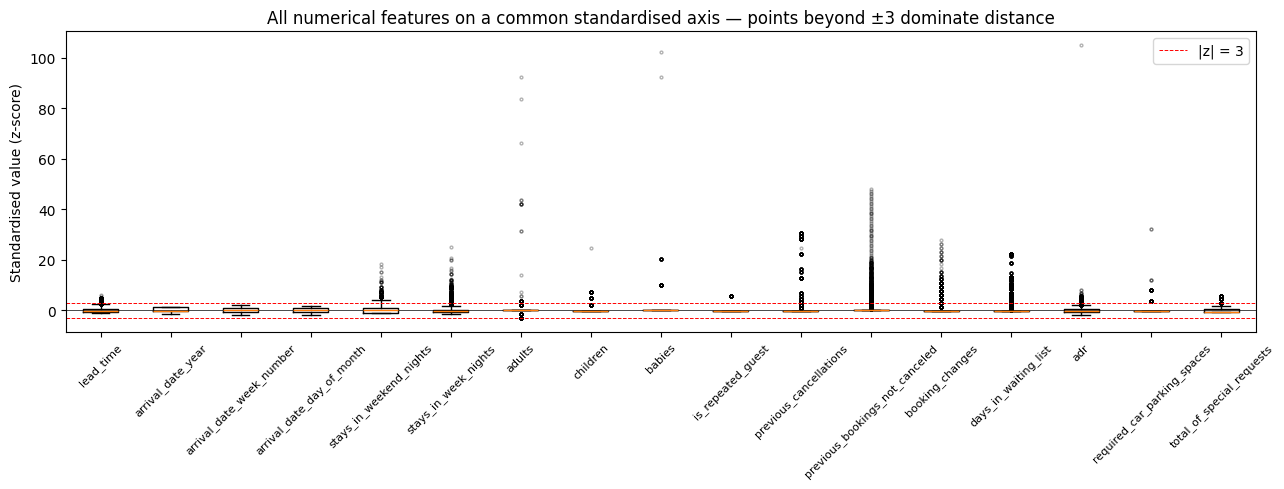

Extreme observations per feature in the standardised space:
                       feature  n_z>3  pct_z>3  n_z>5  max_abs_z
                           adr   1140     0.96     43     105.05
                        babies    917     0.77    917     102.47
                        adults    301     0.25     16      92.39
previous_bookings_not_canceled    933     0.78    551      47.97
   required_car_parking_spaces   7409     6.22     33      32.35
        previous_cancellations    317     0.27    221      30.67
               booking_changes   1532     1.29    618      27.85
          stays_in_week_nights   1652     1.39    339      25.04
                      children   3729     3.13     77      24.81
          days_in_waiting_list   1867     1.57    965      22.09
       stays_in_weekend_nights   2182     1.83    258      18.16
                     lead_time   1453     1.22      2       5.92
     total_of_special_requests   2874     2.41     40       5.59
             is_repeated_guest

In [ ]:
from sklearn.preprocessing import StandardScaler

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Panel 1: all numerical features after z-score scaling (same axis)
scaler_preview = StandardScaler()
X_num_scaled = scaler_preview.fit_transform(df[num_cols].fillna(df[num_cols].median()))
X_num_scaled_df = pd.DataFrame(X_num_scaled, columns=num_cols)

fig, ax = plt.subplots(figsize=(13, 5))
ax.boxplot([X_num_scaled_df[c] for c in num_cols], labels=num_cols, showfliers=True,
           flierprops=dict(marker='o', markersize=2, alpha=0.3))
ax.axhline(0, color='black', linewidth=0.5)
ax.axhline(3, color='red', linestyle='--', linewidth=0.7, label='|z| = 3')
ax.axhline(-3, color='red', linestyle='--', linewidth=0.7)
ax.set_ylabel('Standardised value (z-score)')
ax.set_title('All numerical features on a common standardised axis — points beyond ±3 dominate distance')
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.legend()
plt.tight_layout()
plt.show()


print('Extreme observations per feature in the standardised space:')
extreme_rows = []
for col in num_cols:
    z = X_num_scaled_df[col].abs()
    extreme_rows.append({
        'feature': col,
        'n_z>3': int((z > 3).sum()),
        'pct_z>3': round((z > 3).mean() * 100, 2),
        'n_z>5': int((z > 5).sum()),
        'max_abs_z': round(z.max(), 2),
    })
print(pd.DataFrame(extreme_rows).sort_values('max_abs_z', ascending=False).to_string(index=False))

## Preprocessing Pipeline

**Numerical:** median imputation (robust to outliers/skew) → StandardScaler (z-score normalization)

**Categorical:** mode imputation → rare categories (< 1% frequency) grouped into `"Other"` → OneHotEncoder with `handle_unknown='ignore'` (unseen categories at inference map to all-zero vector)

**Implied distance/metric:** After this pipeline the representation is a dense numeric matrix with standardised numerical columns and binary OHE columns. The natural and implied distance is **Euclidean distance in this standardised mixed space**, which is compatible with k-means and Ward hierarchical clustering.

In [56]:
# Group rare categories (< 1% frequency) into 'Other' before OHE
MIN_FREQ = 0.01
for col in CATEGORICAL:
    freq = df_features[col].value_counts(normalize=True)
    rare = freq[freq < MIN_FREQ].index
    if len(rare) > 0:
        df_features[col] = df_features[col].apply(lambda x: 'Other' if x in rare else x)
        print(f'{col}: {len(rare)} rare categories grouped into "Other"')

meal: 2 rare categories grouped into "Other"
country: 163 rare categories grouped into "Other"
market_segment: 3 rare categories grouped into "Other"
distribution_channel: 2 rare categories grouped into "Other"
reserved_room_type: 4 rare categories grouped into "Other"
deposit_type: 1 rare categories grouped into "Other"
customer_type: 1 rare categories grouped into "Other"


In [57]:
numerical_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale',  StandardScaler()),
])

categorical_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('encode', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ('num', numerical_pipeline,  NUMERICAL),
    ('cat', categorical_pipeline, CATEGORICAL),
], remainder='drop')

X = preprocessor.fit_transform(df_features)

ohe_names = (
    preprocessor
    .named_transformers_['cat']
    .named_steps['encode']
    .get_feature_names_out(CATEGORICAL)
    .tolist()
)
feature_names = NUMERICAL + ohe_names
X_df = pd.DataFrame(X, columns=feature_names, index=df_features.index)

print(f'Final matrix shape : {X_df.shape}')
print(f'  - Numerical dims : {len(NUMERICAL)}')
print(f'  - OHE dims       : {len(ohe_names)}')
print(f'  - Total samples  : {X_df.shape[0]:,}')
print(f'NaN in output      : {X_df.isnull().sum().sum()}')

Final matrix shape : (119210, 73)
  - Numerical dims : 17
  - OHE dims       : 56
  - Total samples  : 119,210
NaN in output      : 0


## Final Feature Set Summary

| | |
|---|---|
| **Samples** | see output above |
| **Numerical features** | 17 (standardised, median-imputed) |
| **Categorical features** | 10 (one-hot encoded, rare→Other) |
| **Total dimensions after OHE** | see output above |
| **Implied distance** | Euclidean in standardised mixed space |
| **Compatible algorithms** | k-means, MiniBatch k-means, Ward hierarchical |
| **Excluded (leakage)** | `is_canceled`, `reservation_status`, `reservation_status_date` |
| **Excluded (ID-like)** | `agent`, `company` |
| **Retained for profiling only** | `is_canceled`, `reservation_status` |

**Relevance to RQ1:** The 17 numerical features directly capture the behavioural signals expected to differ between business and leisure travellers — particularly `lead_time` (business: short, leisure: long), `stays_in_week_nights` vs `stays_in_weekend_nights` (business: weekday-heavy), `adr` (business: premium rates), and `total_of_special_requests`. The categorical features (market segment, distribution channel, meal, deposit type) encode the booking context. Together they provide a rich, leakage-free representation for travel-purpose segmentation.

# Task 1.2 - Learn a baseline clustering model

We evaluated k = {3,4,5,6,7} because values below 3 are too coarse for our objective (they cannot capture the expected heterogeneity beyond a single “business vs leisure” split), while values much above 7 tend to produce clusters that are too small and difficult to interpret/action in a hotel revenue‑management setting. The range 3–7 is therefore domain‑plausible for segmentation (allowing a business/leisure split plus potential micro‑segments such as “families”, “weekend couples”, etc.) while keeping interpretation manageable.


In [63]:
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import calinski_harabasz_score
from sklearn.model_selection import train_test_split

kvalues = range(3, 9) # Test k = 3 to 7 clusters (5 total)
SEEDS = range(17341, 17347)  # Multiple seeds for stability check
sample_indices = train_test_split(X_df.index, train_size=0.8, random_state=SEEDS[0])
X_train = X_df.loc[sample_indices[0]]
X_val = X_df.loc[sample_indices[1]]
train_results = []
val_results = []
for k in kvalues:
    print(f'\n=== Clustering with k={k} ===')
    for seed in SEEDS:

        baseline = KMeans(n_clusters=k, random_state=seed)
        labels_train = baseline.fit_predict(X_train)
        s_score = silhouette_score(X_train, labels_train, sample_size=5000)
        train_results.append({'k': k, 'seed': seed, 'silhouette': s_score})
        db_score = davies_bouldin_score(X_train, labels_train)
        train_results.append({'k': k, 'seed': seed, 'davies_bouldin': db_score})
        ch_score = calinski_harabasz_score(X_train, labels_train)
        train_results.append({'k': k, 'seed': seed, 'calinski_harabasz': ch_score})
        print(f'KMeans k={k} seed={seed} -> silhouette={s_score:.4f}, davies_bouldin={db_score:.4f}, calinski_harabasz={ch_score:.4f}')
        # Check scores in other 80% to check stability of clusters
        labels_val = baseline.predict(X_val)
        s_score_val = silhouette_score(X_val, labels_val, sample_size=5000)
        val_results.append({'k': k, 'seed': seed, 'silhouette': s_score_val})
        db_score_val = davies_bouldin_score(X_val, labels_val)
        val_results.append({'k': k, 'seed': seed, 'davies_bouldin': db_score_val})
        ch_score_val = calinski_harabasz_score(X_val, labels_val)
        val_results.append({'k': k, 'seed': seed, 'calinski_harabasz': ch_score_val})
        print(f'Validation scores -> silhouette={s_score_val:.4f}, davies_bouldin={db_score_val:.4f}, calinski_harabasz={ch_score_val:.4f}')
        


=== Clustering with k=3 ===
KMeans k=3 seed=17341 -> silhouette=0.0850, davies_bouldin=2.8849, calinski_harabasz=5719.0604
Validation scores -> silhouette=0.0795, davies_bouldin=2.8883, calinski_harabasz=1367.3128
KMeans k=3 seed=17342 -> silhouette=0.0673, davies_bouldin=3.0341, calinski_harabasz=5773.4864
Validation scores -> silhouette=0.0623, davies_bouldin=3.0275, calinski_harabasz=1407.0598
KMeans k=3 seed=17343 -> silhouette=0.0703, davies_bouldin=3.0341, calinski_harabasz=5773.4917
Validation scores -> silhouette=0.0692, davies_bouldin=3.0274, calinski_harabasz=1407.0696
KMeans k=3 seed=17344 -> silhouette=0.0719, davies_bouldin=3.0341, calinski_harabasz=5773.4712
Validation scores -> silhouette=0.0663, davies_bouldin=3.0275, calinski_harabasz=1407.0327
KMeans k=3 seed=17345 -> silhouette=0.0719, davies_bouldin=3.0348, calinski_harabasz=5773.3250
Validation scores -> silhouette=0.0714, davies_bouldin=3.0273, calinski_harabasz=1407.2813
KMeans k=3 seed=17346 -> silhouette=0.073

#### Silhouette Score: Range is [-1,1] where 1 is the best
#### Davies Bouldin Score: Range is [0, +∞] where 0 is best
#### Calinski Harabasz: Range is [0, +∞] where +∞ is best

In [59]:
# Build DataFrame and collapse to one row per k & seed with all three metrics
results_df = pd.DataFrame(train_results)
train_df_runs = results_df.groupby(['k', 'seed']).max().reset_index()
metrics = ['silhouette', 'davies_bouldin', 'calinski_harabasz']
agg = train_df_runs.groupby(['k'])[metrics].agg(['mean', 'std']).round(4)

# Display table: mean ± std per k
print('\n=== Training clustering results (mean ± std over 5 seeds) ===')
table_rows = []
for k, row in agg.iterrows():
    r = {'k': k}
    for m in metrics:
        mu, sig = row[(m, 'mean')], row[(m, 'std')]
        r[m] = f'{mu:.4f} ± {sig:.4f}'
    table_rows.append(r)
table_df = pd.DataFrame(table_rows).set_index('k')
display(table_df)

# Validation results
results_df = pd.DataFrame(val_results)
val_df_runs = results_df.groupby(['k', 'seed']).max().reset_index()
metrics = ['silhouette', 'davies_bouldin', 'calinski_harabasz']
agg = val_df_runs.groupby(['k'])[metrics].agg(['mean', 'std']).round(4)

# Display table: mean ± std per (clustering, k)
print('\n=== Clustering results (mean ± std over 5 seeds) ===')
table_rows = []
for k, row in agg.iterrows():
    r = {'k': k}
    for m in metrics:
        mu, sig = row[(m, 'mean')], row[(m, 'std')]
        r[m] = f'{mu:.4f} ± {sig:.4f}'
    table_rows.append(r)
table_df = pd.DataFrame(table_rows).set_index('k')
display(table_df)


=== Training clustering results (mean ± std over 5 seeds) ===


,silhouette,davies_bouldin,calinski_harabasz
k,,,
3,0.0741 ± 0.0077,2.9664 ± 0.1300,1480.9605 ± 71.3253
4,0.0751 ± 0.0117,2.5836 ± 0.2838,1452.5477 ± 131.2199
5,0.0773 ± 0.0069,2.3830 ± 0.2011,1448.8645 ± 132.8652
6,0.0830 ± 0.0024,2.2442 ± 0.1649,1429.9347 ± 117.6946
7,0.0868 ± 0.0090,2.1398 ± 0.1440,1411.4037 ± 80.5936
8,0.0927 ± 0.0081,2.0072 ± 0.1554,1449.4497 ± 83.6071



=== Clustering results (mean ± std over 5 seeds) ===


,silhouette,davies_bouldin,calinski_harabasz
k,,,
3,0.0730 ± 0.0080,2.9664 ± 0.1244,5806.9969 ± 293.5946
4,0.0740 ± 0.0114,2.5819 ± 0.2670,5663.0743 ± 475.1884
5,0.0765 ± 0.0052,2.3842 ± 0.1950,5663.9955 ± 499.2454
6,0.0819 ± 0.0031,2.2548 ± 0.1646,5538.8925 ± 412.3965
7,0.0842 ± 0.0079,2.1470 ± 0.1450,5469.1985 ± 237.8501
8,0.0901 ± 0.0095,2.0062 ± 0.1535,5656.8467 ± 243.0320


In [60]:
# Plot Task 1.2 — KMeans: spread of each metric across 5 seeds vs k
def plot_metric_spread(df_runs, metrics, metric_labels, title, filename):
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    for ax, m, label in zip(axes, metrics, metric_labels):
        grouped = df_runs.groupby('k')[m]
        mean = grouped.mean()
        low = grouped.min()
        high = grouped.max()
        ax.fill_between(mean.index, low, high, alpha=0.25)
        ax.plot(mean.index, mean.values, marker='o')
        ax.set_xlabel("k")
        ax.set_ylabel(label)
        ax.grid(True, alpha=0.3)

    plt.suptitle(
        title,
        fontsize=11,
    )
    plt.tight_layout()
    plt.show()
    os.makedirs('plots', exist_ok=True)
    fig.savefig(f'plots/{filename}', dpi=300)

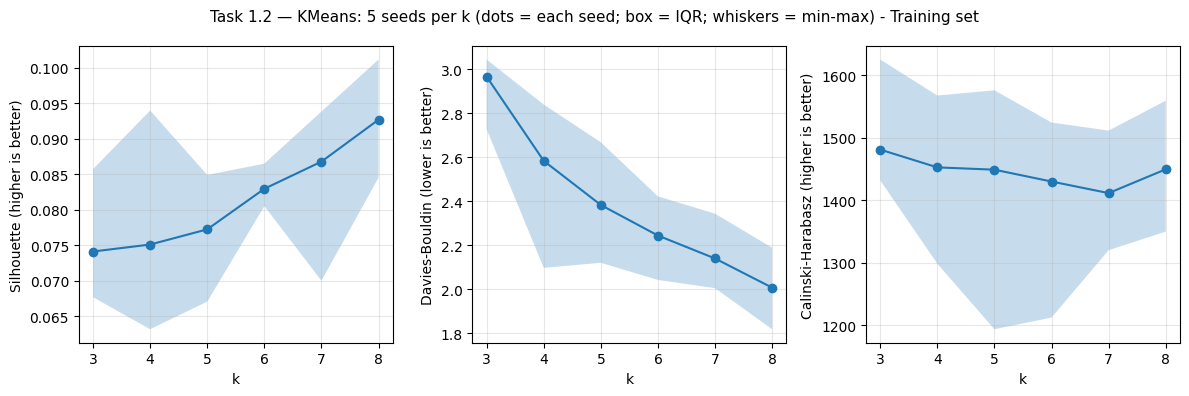

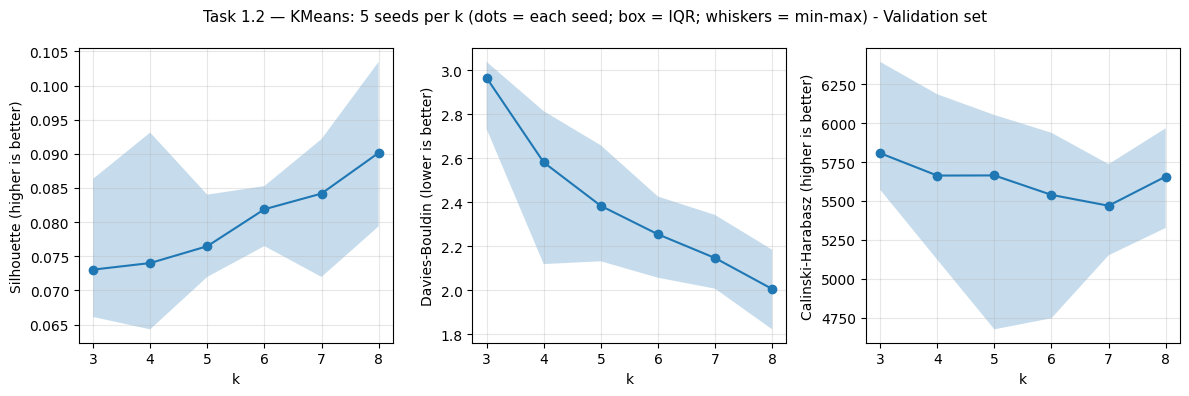

In [61]:
# Plot training metrics
plot_metric_spread(
    train_df_runs,
    metrics=['silhouette', 'davies_bouldin', 'calinski_harabasz'],
    metric_labels=[
        'Silhouette (higher is better)',
        'Davies-Bouldin (lower is better)',
        'Calinski-Harabasz (higher is better)',
    ],
    title='Task 1.2 — KMeans: 5 seeds per k (dots = each seed; box = IQR; whiskers = min-max) - Training set',
    filename='task1_2_clustering_metrics_train.png'
)

# Plot validation metrics
plot_metric_spread(
    val_df_runs,
    metrics=['silhouette', 'davies_bouldin', 'calinski_harabasz'],
    metric_labels=[
        'Silhouette (higher is better)',
        'Davies-Bouldin (lower is better)',
        'Calinski-Harabasz (higher is better)',
    ],
    title='Task 1.2 — KMeans: 5 seeds per k (dots = each seed; box = IQR; whiskers = min-max) - Validation set',
    filename='task1_2_clustering_metrics_val.png'
)

In [64]:
results = []
for seed in SEEDS:
    ward_model = AgglomerativeClustering(n_clusters=k, linkage='ward')
    ward_labels = ward_model.fit_predict(X_train)
    ward_s_score = silhouette_score(X_train, ward_labels, sample_size=5000, random_state=seed)
    results.append({'clustering': 'Ward', 'k': k, 'seed': seed, 'silhouette': ward_s_score})
    ward_db_score = davies_bouldin_score(X_train, ward_labels)
    results.append({'clustering': 'Ward', 'k': k, 'seed': seed, 'davies_bouldin': ward_db_score})
    ward_ch_score = calinski_harabasz_score(X_train, ward_labels)
    results.append({'clustering': 'Ward', 'k': k, 'seed': seed, 'calinski_harabasz': ward_ch_score})
    print(f'Ward k={k} seed={seed} -> silhouette={ward_s_score:.4f}, davies_bouldin={ward_db_score:.4f}, calinski_harabasz={ward_ch_score:.4f}')

KeyboardInterrupt: 

1. Rephrase the objective more cautiously. Instead of stating that the project will segment business and leisure travellers, state that it will discover booking profiles that may correspond to business - or leisure - like patterns. This is more faithful to an unsupervised problem without labels.
2. State the unit of analysis and the segmentation time explicitly. The brief defines each row as one booking record, and clustering inputs should be limited to information known when the booking is  assigned to a segment. This should be stated explicitly in the specification.
3. Tighten the final feature set. Each selected variable should be audited against booking-time availability. In particular, reserved_room_type is easier to justify than assigned_room_type, and any variable that evolves after booking should be excluded unless its timing is clearly justified.
4. Distinguish clustering inputs from post hoc profiling variables. Some variables may be better used to describe the clusters after they are formed rather than to create them. This will make the interpretation cleaner and reduce the risk of circular reasoning.
5. Ensure that the full project follows the protocol required in the brief. The specification already points naturally towards k-means and Ward. For the final project, it should also include the required baseline and evaluation structure: k-means, ik-means, one additional family, justified parameter ranges, internal validity indices, stability analysis, and one controlled preprocessing variant.
6. Definir melhor a família adicional a considerar (no nosso caso hierarchical)

### Questions to ask teacher:

1. Tratar o i-kmeans como experiencia a parte ou apenas como inicializacao nos experiments em comparacao com por exemplo kmeans++.csv


Modelar quando parar o algoritmo. Afinar com experimental dataset este parametros

IKMEANS - APROVEITAR O IK DAR OS CLUSTER SEM SER PRIORI.

Fazer uma versao com dados mistos, e sem dados mistos.

Olhar para encoding nos acetatos. Paises main e other.

2. Hotel feature mostra nao imensas diferencas entre hoteis, manter juntos ?

Justificar porque nao usamos. Deitamo-la fora.

3. O silhouette prova ser computacionalmente intenso para o ds todo, fazemos subsampling, Prefere (a) uma sub-amostra única com seed fixa e estimativa pontual, (b) sub-sampling com bootstrap e intervalo de confiança reportado, ou (c) aproximação tipo MiniBatch


(b) passar o subsampling para os algoritmos sempre o mesmo. definir isso.  A prof deu um subsampling. Com amostras estratificadas dentro da raiz do problema. Variaveis proxies para ter uma amostra proxy.

4. Como sensitivity plan, na secção 6 do Milestone 2 (Sensitivity / robustness plan), a minha proposta é a seguinte:

Variante: eliminar uma feature de cada par categórico com Cramér's V > 0.5. A minha EDA detectou redundância forte entre `market_segment` ↔ `distribution_channel` (V > 0.5) e entre `reserved_room_type` ↔ `assigned_room_type`, e o objectivo é reduzir a dominância destas no espaço OHE.

Jusitifcação: os perfis de clusters identificados pelo baseline são robustos à remoção desta redundância categórica, ou o baseline está a duplicar sinal?

OU:

- Encoding cíclico do mês em vex de OHE. I.e jan-0 feb-1 -> jan -> sin(2π × 1 / 12) && cos(2π × 1 / 12)
- RobustScaling -> Para controlar impacto de outliers


Diferentes datasets com designação distinta. correr os pipelines em cada uma. 